# Import Packages

In [6]:
#!pip install numpy
#!pip install opencv-contrib-python
#!pip install tensorflow
#!pip install tqdm
#!pip install matplotlib
#!pip install seaborn
#!pip install pandas
#!pip install scikit-learn

In [7]:
import numpy as np
import os
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
from tqdm import tqdm
import pandas as pd
%matplotlib inline
import seaborn as sns


In [8]:

brain_class = ['No-tumor','Pituitary','Meningioma','Glioma']


brain_class_labels = {class_name: i for i, class_name in enumerate(brain_class)}
nb_classes = len(brain_class)
BRAIN_IMAGE_SIZE = (150, 150)


# LOADING DATABASE AND PRE-PROCESS

In [11]:
import os
import cv2
import numpy as np
from tqdm import tqdm

brain_train_path = r"train"
brain_test_path = r"test"

BRAIN_IMAGE_SIZE = (150, 150)

brain_class_labels = {
    "No-tumor": 0,
    "Pituitary": 1,
    "Meningioma": 2,
    "Glioma": 3,

}

VALID_EXTENSIONS = (".png", ".jpg", ".jpeg")


def load_brain_data():
    datasets = [brain_train_path, brain_test_path]
    output = []

    for dataset in datasets:
        images, labels = [], []
        print(f"\n📂 Loading from: {dataset}")

        for category in os.listdir(dataset):
            if category not in brain_class_labels:
                continue

            label = brain_class_labels[category]
            category_path = os.path.join(dataset, category)

            for file in tqdm(os.listdir(category_path), desc=category):
                
                if file.startswith("._"):
                    continue
                if not file.lower().endswith(VALID_EXTENSIONS):
                    continue

                img_path = os.path.join(category_path, file)
                image = cv2.imread(img_path)

                if image is None:
                    continue

                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                image = cv2.resize(image, BRAIN_IMAGE_SIZE)

                images.append(image)
                labels.append(label)

        images = np.array(images, dtype="float32") / 255.0
        labels = np.array(labels, dtype="int32")

        print(f"✅ Loaded {len(images)} valid images from {dataset}")
        output.append((images, labels))

    return output



In [12]:
(train_images, train_labels), (test_images, test_labels) = load_brain_data()



📂 Loading from: train


Pituitary: 100%|██████████| 308/308 [00:06<00:00, 46.00it/s]


✅ Loaded 1243 valid images from train

📂 Loading from: test


Pituitary: 100%|██████████| 308/308 [00:03<00:00, 79.70it/s]


✅ Loaded 1243 valid images from test


In [13]:
train_images, train_labels = shuffle(train_images, train_labels, random_state=25)

print(f"Number of training examples: {train_labels.shape[0]}")
print(f"Number of testing examples: {test_labels.shape[0]}")
print(f"Each image is of size: {BRAIN_IMAGE_SIZE}")


Number of training examples: 1243
Number of testing examples: 1243
Each image is of size: (150, 150)


# DATA VISUALIZATION

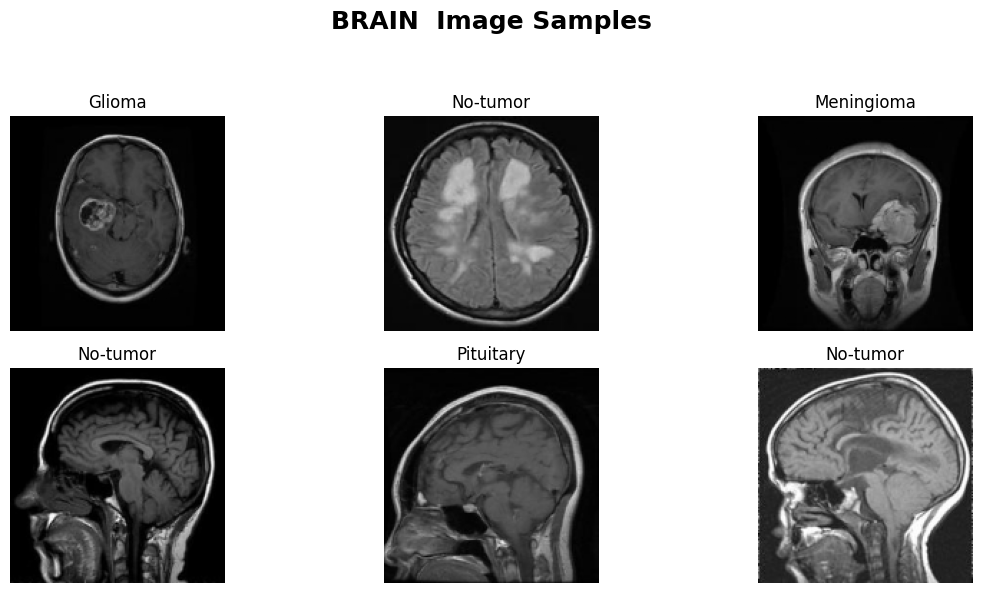

In [14]:
import matplotlib.pyplot as plt

index_to_class = {v: k for k, v in brain_class_labels.items()}

def display_examples(images, labels):
    plt.figure(figsize=(12, 6))
    plt.suptitle("BRAIN  Image Samples", fontsize=18, fontweight="bold")

    for i in range(6):
        plt.subplot(2, 3, i + 1)
        plt.imshow(images[i])
        plt.title(index_to_class[labels[i]], fontsize=12)
        plt.axis("off")

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()


display_examples(train_images, train_labels)


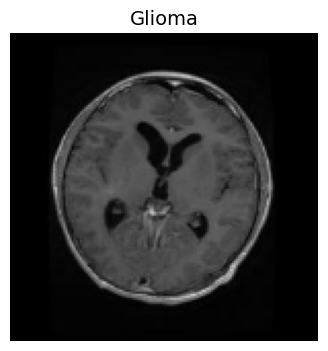

In [15]:
import matplotlib.pyplot as plt
import numpy as np

index_to_class = {v: k for k, v in brain_class_labels.items()}

def show_random_image(images, labels):
    idx = np.random.randint(len(images))
    
    plt.figure(figsize=(4, 4))
    plt.imshow(images[idx])
    plt.title(f"{index_to_class[labels[idx]]}", fontsize=14)
    plt.axis("off")
    plt.show()


show_random_image(train_images, train_labels)


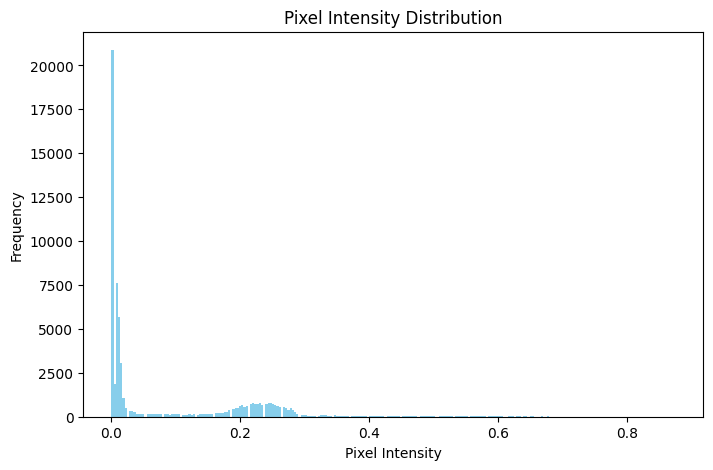

In [16]:
def plot_pixel_intensity_histogram(image):
    plt.figure(figsize=(8, 5))
    plt.hist(image.ravel(), bins=256, color='skyblue')
    plt.title('Pixel Intensity Distribution')
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Frequency')
    plt.show()


plot_pixel_intensity_histogram(train_images[0])


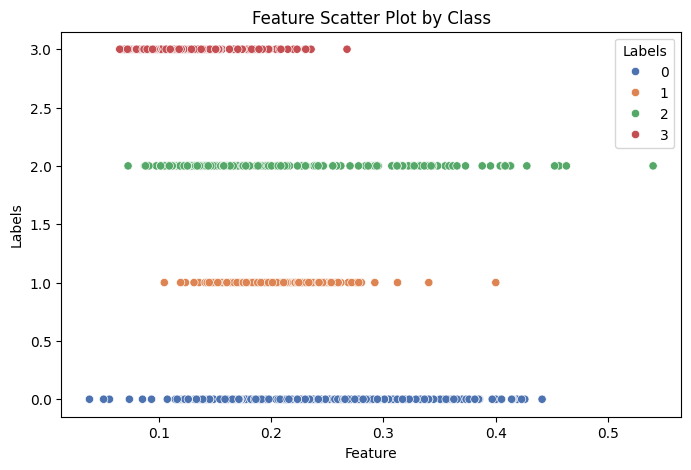

In [17]:
df = pd.DataFrame({'Labels': train_labels, 'Feature': [np.mean(img) for img in train_images]})
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Feature', y='Labels', hue='Labels', palette='deep')
plt.title('Feature Scatter Plot by Class')
plt.show()


C:\Users\aanil\AppData\Local\Temp\ipykernel_27496\1404880527.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Labels', y='Feature', palette='muted')


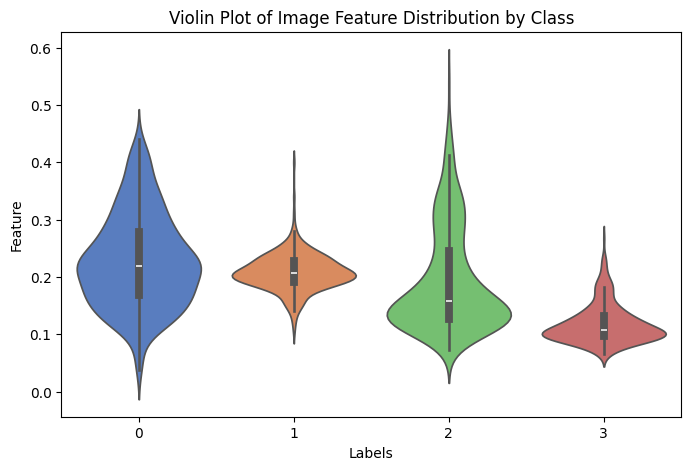

In [18]:
df = pd.DataFrame({'Labels': train_labels, 'Feature': [np.mean(img) for img in train_images]})
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x='Labels', y='Feature', palette='muted')
plt.title('Violin Plot of Image Feature Distribution by Class')
plt.show()


<Figure size 800x500 with 0 Axes>

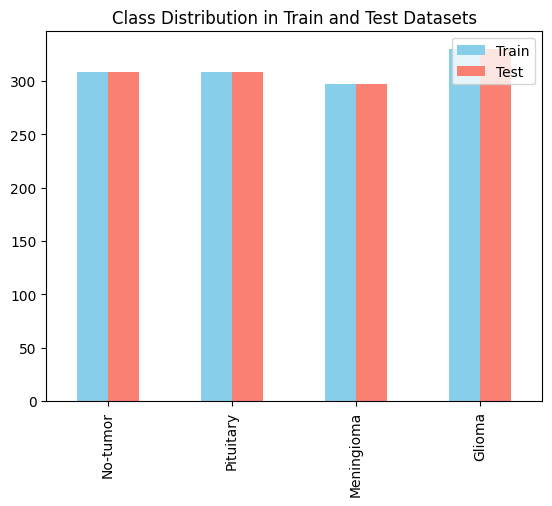

In [19]:

_, train_class_counts = np.unique(train_labels, return_counts=True)
_, test_class_counts = np.unique(test_labels, return_counts=True)


plt.figure(figsize=(8, 5))
pd.DataFrame({'Train': train_class_counts, 'Test': test_class_counts}, index=brain_class).plot.bar(color=['skyblue', 'salmon'])
plt.title('Class Distribution in Train and Test Datasets')
plt.show()


# MODEL

In [20]:
import tensorflow as tf


NUM_CLASSES = len(brain_class_labels)


model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(
        32, (3, 3),
        activation='relu',
        input_shape=(BRAIN_IMAGE_SIZE[0], BRAIN_IMAGE_SIZE[1], 3)
    ),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])


model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_images,
    train_labels,
    batch_size=16,
    epochs=10,
    validation_split=0.2,
    shuffle=True
)


C:\Users\aanil\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 247ms/step - accuracy: 0.6097 - loss: 1.0134 - val_accuracy: 0.7671 - val_loss: 0.6092
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 250ms/step - accuracy: 0.8541 - loss: 0.4115 - val_accuracy: 0.8313 - val_loss: 0.5340
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 18s 282ms/step - accuracy: 0.9316 - loss: 0.2077 - val_accuracy: 0.8474 - val_loss: 0.4290
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 227ms/step - accuracy: 0.9668 - loss: 0.0962 - val_accuracy: 0.8394 - val_loss: 0.5949
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 266ms/step - accuracy: 0.9839 - loss: 0.0482 - val_accuracy: 0.8755 - val_loss: 0.5163
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 211ms/step - accuracy: 0.9930 - loss: 0.0274 - val_accuracy: 0.8715 - val_loss: 0.5276
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 193ms/step - accuracy: 0.9990 - loss: 0.0101 - val_accuracy: 0.8755 - val_loss: 0.6363
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 222ms/step - accuracy: 0.9879 - loss: 0.0341 - val_accu

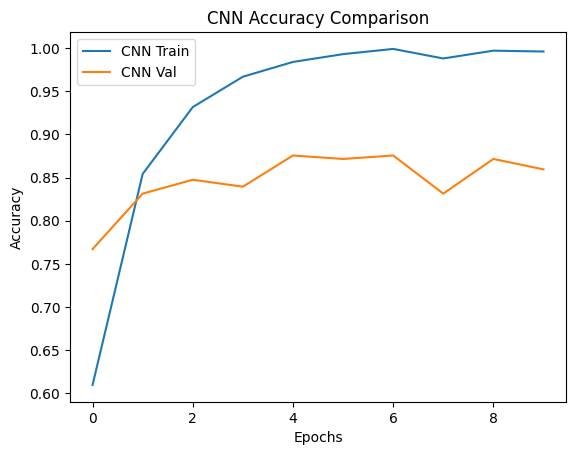

In [21]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('CNN Accuracy Comparison')
plt.legend(['CNN Train', 'CNN Val'])
plt.show()


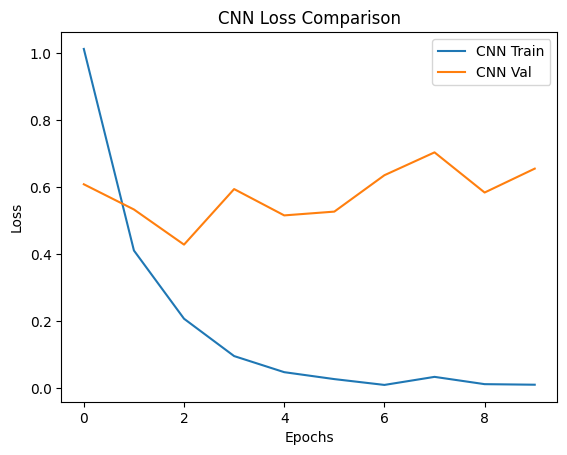

In [22]:
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('CNN Loss Comparison')
plt.legend(['CNN Train', 'CNN Val'])
plt.show()


In [23]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np


y_pred_probs = model.predict(test_images)


y_pred = np.argmax(y_pred_probs, axis=1)


class_names = list(brain_class_labels.keys())


print("\n📊 Classification Report:\n")
print(
    classification_report(
        test_labels,
        y_pred,
        target_names=class_names,
        digits=4
    )
)


39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step

📊 Classification Report:

              precision    recall  f1-score   support

    No-tumor     0.9868    0.9708    0.9787       308
   Pituitary     0.9935    0.9870    0.9902       308
  Meningioma     0.9233    0.9731    0.9475       297
      Glioma     0.9782    0.9515    0.9647       330

    accuracy                         0.9702      1243
   macro avg     0.9704    0.9706    0.9703      1243
weighted avg     0.9710    0.9702    0.9704      1243



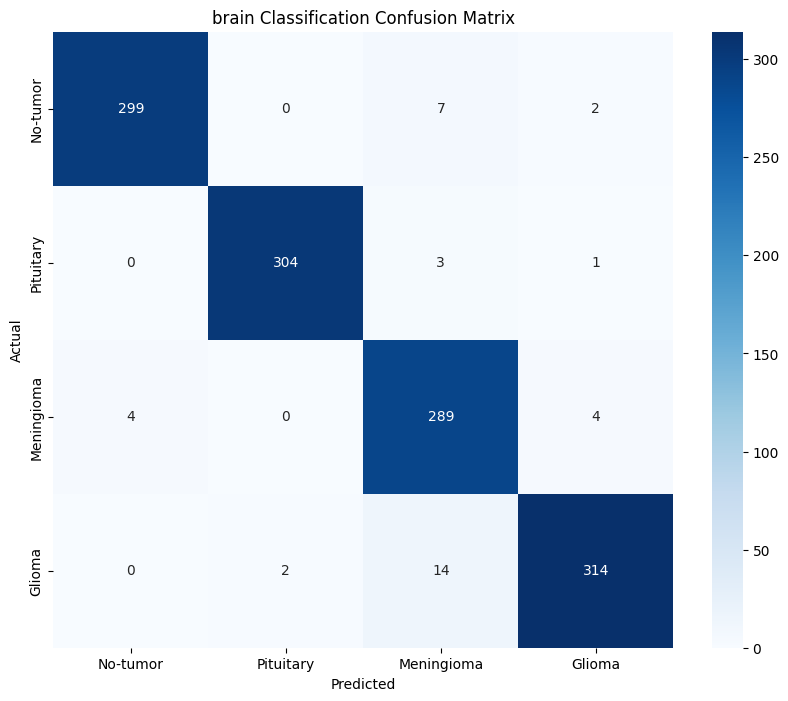

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(test_labels, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("brain Classification Confusion Matrix")
plt.show()


In [25]:
model.save("brain.h5")
model_json = model.to_json()
with open("brain.json", "w") as json_file:
    json_file.write(model_json)

print("Model saved as 'brain.h5' and 'brain.json'.")


Model saved as 'brain.h5' and 'brain.json'.
